### Exploratory Data Analysis (EDA) - Financial News


### Descriptive Statistics

#### 1. Data Loading and Basic Statistics

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [ ]:
# Load data
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')



In [10]:
# 1. Basic Stats for Textual Lengths
df['headline_len'] = df['headline'].apply(len)

print("--- Headline Length Statistics ---")
print(df['headline_len'].describe())


--- Headline Length Statistics ---
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


In [11]:
# 3. Publisher Analysis
# Cleaning publisher names (extracting domains if they are emails)
df['publisher_cleaned'] = df['publisher'].apply(lambda x: x.split('@')[-1] if '@' in str(x) else x)
top_publishers = df['publisher_cleaned'].value_counts().head(10)

print("\n--- Top 10 Active Publishers ---")
print(top_publishers)




--- Top 10 Active Publishers ---
publisher_cleaned
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


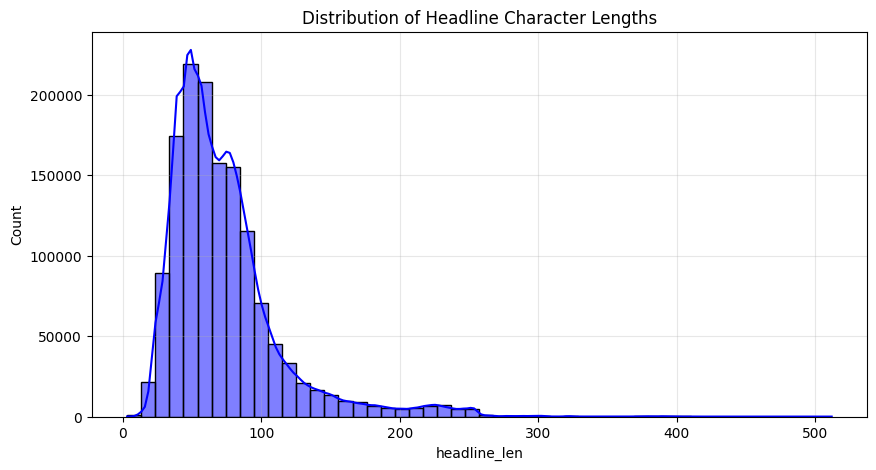

In [17]:
# Visualization 1: Headline Length Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['headline_len'], bins=50, kde=True, color='blue')
plt.title('Distribution of Headline Character Lengths')
plt.grid(alpha=0.3)
plt.show()

#### Time Series Analysis
We analyze how news volume varies over time to identify specific dates where market-moving events may have caused spikes in reporting.

In [13]:
# 1. Convert date to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [14]:
# 2. Aggregating by day
df['pub_day'] = df['date'].dt.date
daily_counts = df['pub_day'].value_counts().sort_index()

In [15]:
# 3. Identify Spikes
spikes = daily_counts.nlargest(5)
print("--- Top 5 Dates with News Spikes ---")
print(spikes)

--- Top 5 Dates with News Spikes ---
pub_day
2020-03-12    973
2020-06-05    932
2020-06-10    806
2020-06-09    804
2020-06-08    765
Name: count, dtype: int64


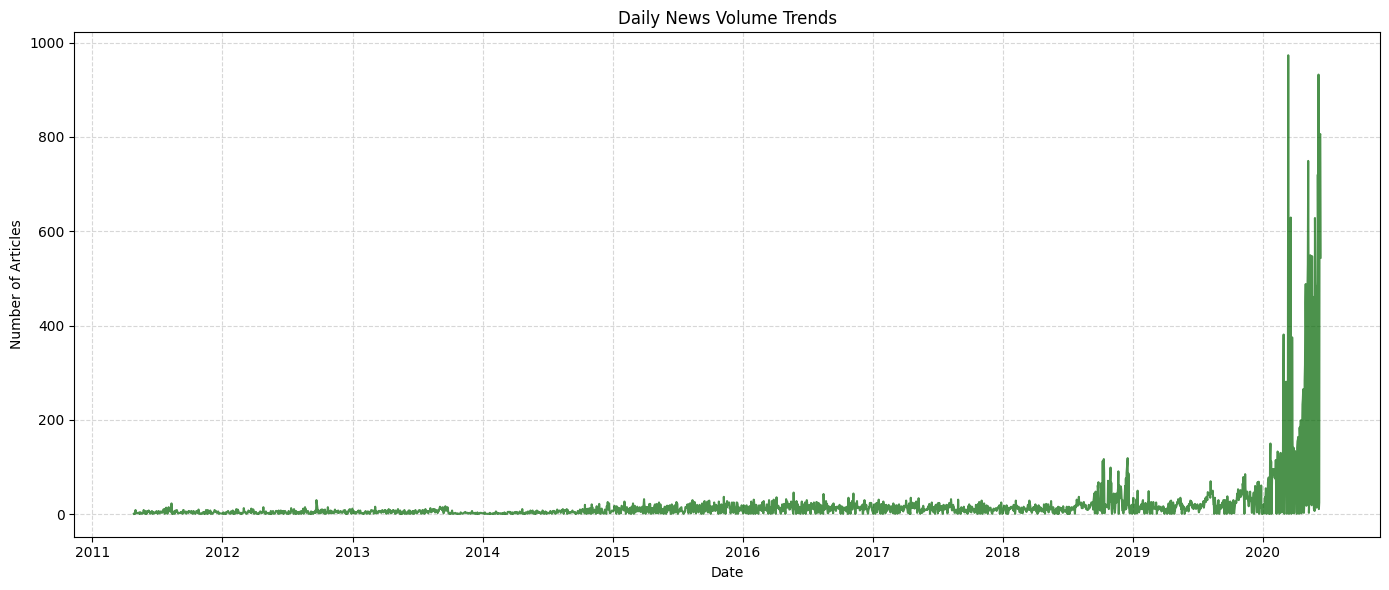

In [16]:
# Visualization 2: News Volume Over Time
plt.figure(figsize=(14, 6))
daily_counts.plot(kind='line', color='darkgreen', alpha=0.7)
plt.title('Daily News Volume Trends')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()